# 9. 모델에 외생 변수 추가하기

지금까지는 시계열 자체만 고려. 즉, 시계열의 과것값을 미랫값의 예측 변수로 사용. 그러나 외생 변수도 시계열에 영향을 미칠 수 있으므로 미랫값을 예측하는 데 좋은 예측 변수가 될 수 있음.  
SARIMAX 모델: 외생 변수를 나타내는 X 항이 추가. 
- Exogenous Variable: 예측 변수 또는 입력 변수를 설명
- Endogenous Variable: 예측하고자 하는 대상 변수를 정의하는데 사용

1959 - 2009년의 GDP 예시

In [1]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

macro_econ_data = sm.datasets.macrodata.load_pandas().data
macro_econ_data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


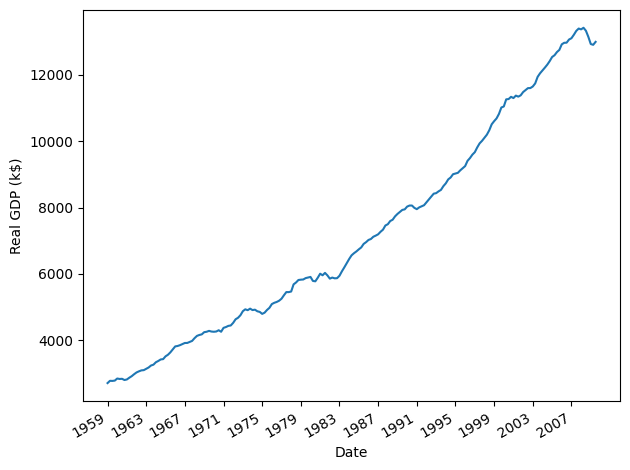

In [2]:
fig, ax = plt.subplots()

ax.plot(macro_econ_data['realgdp'])
ax.set_xlabel('Date')
ax.set_ylabel('Real GDP (k$)')

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))

fig.autofmt_xdate()
plt.tight_layout()


주기적 패턴 없이 수년에 걸쳐 뚜렷한 양의 추세 --> 수열에 계절성이 존재하지 않음.

실질 GDP는 인플레이션을 반영한 지표; 인플레이션이 상품의 시장 가치에 미치는 영향을 제거한 측정값. 인플레이션의 영향을 제거하면 한 국가의 경제에서 생산이 확대되고 있는지 여부를 잘 판단할 수 있음.

GDP 공식:  
GDP = $C + G + I + NX$  
- 각 요소는 외생 변수의 영향을 받을 가능성 높음
    - 예시) 소비는 실업률의 영향을 받을 가능성이 높음. 고용된 사람이 줄어들면 소비가 감소할 가능성이 높기 때문. 
    - 금리가 오르면 돈을 빌리기가 어려워지고, 결과적으로 지출이 감소하기 때문에 금리도 영향을 미칠 수 있음. 
    - 환율은 순수출에 영향을 미친다 생각할 수도 있음. 현지 통화가 약세를 보이면 일반적으로 수출은 촉진되고 수입은 더 비싸짐. 

그래서 실질 GDP에 영향을 미칠 수 있는 외생 변수가 얼마나 많은지 알 수 있음.

# 9.1 SARIMAX 모델 살펴보기

SARIMA(p,d,q)(P,D,Q)$_m$에 외생변수 $X_t$를 추가하여 현잿값 $y_t$로 간단히 표현.  
$y_t = \text{SARIMA}(p,d,q)(P,D,Q)_m + \sum_{i=1}^{n} \beta_i X_t^i $

SARIMA 모델은 과거 수열값과 오차 항의 선형 조합이므로 선형 모델. SARIMAX도 선형 모델. 마찬가지로 인코딩(숫자값 또는 이진 플래그 부여)해야 함.  

<u>계절성은 없지만</u> 외생 변수가 있는 모델을 ARIMAX 모델; 계절성이 없고 외생변수가 없는 모델을 ARIMA.

## 9.1.1 미국 거시경제 데이터 집합의 외생 변수 탐색.  

In [3]:
macro_econ_data = sm.datasets.macrodata.load_pandas().data
macro_econ_data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


일부 column 설명:
- realgdp: 실질 GDP (목표 변수 또는 내생 변수)
- realcons: 실질 개인 소비 지출
- realinv: 실질 국내 총 민간 투자
- realgovt: 실질 연방 소비 지출 및 투자
- realdpi: 실질 민간 가처분 소득
- tbilrate: 3개월 만기 국채의 분기별 월평균 금리
- realint: 실질 이자율

선형 모델은 대상을 예측하는 데 중요하지 않은 외생 변수에 대해 0에 가까운 계수를 보여하기 때문에 특징 선택 (feature selection)을 수행할 필요 없음.  
여기서는 realgdp와 realcons 부터 cpi까지 외생 변수로 삼아, 여섯 가지 변수만 사용.  

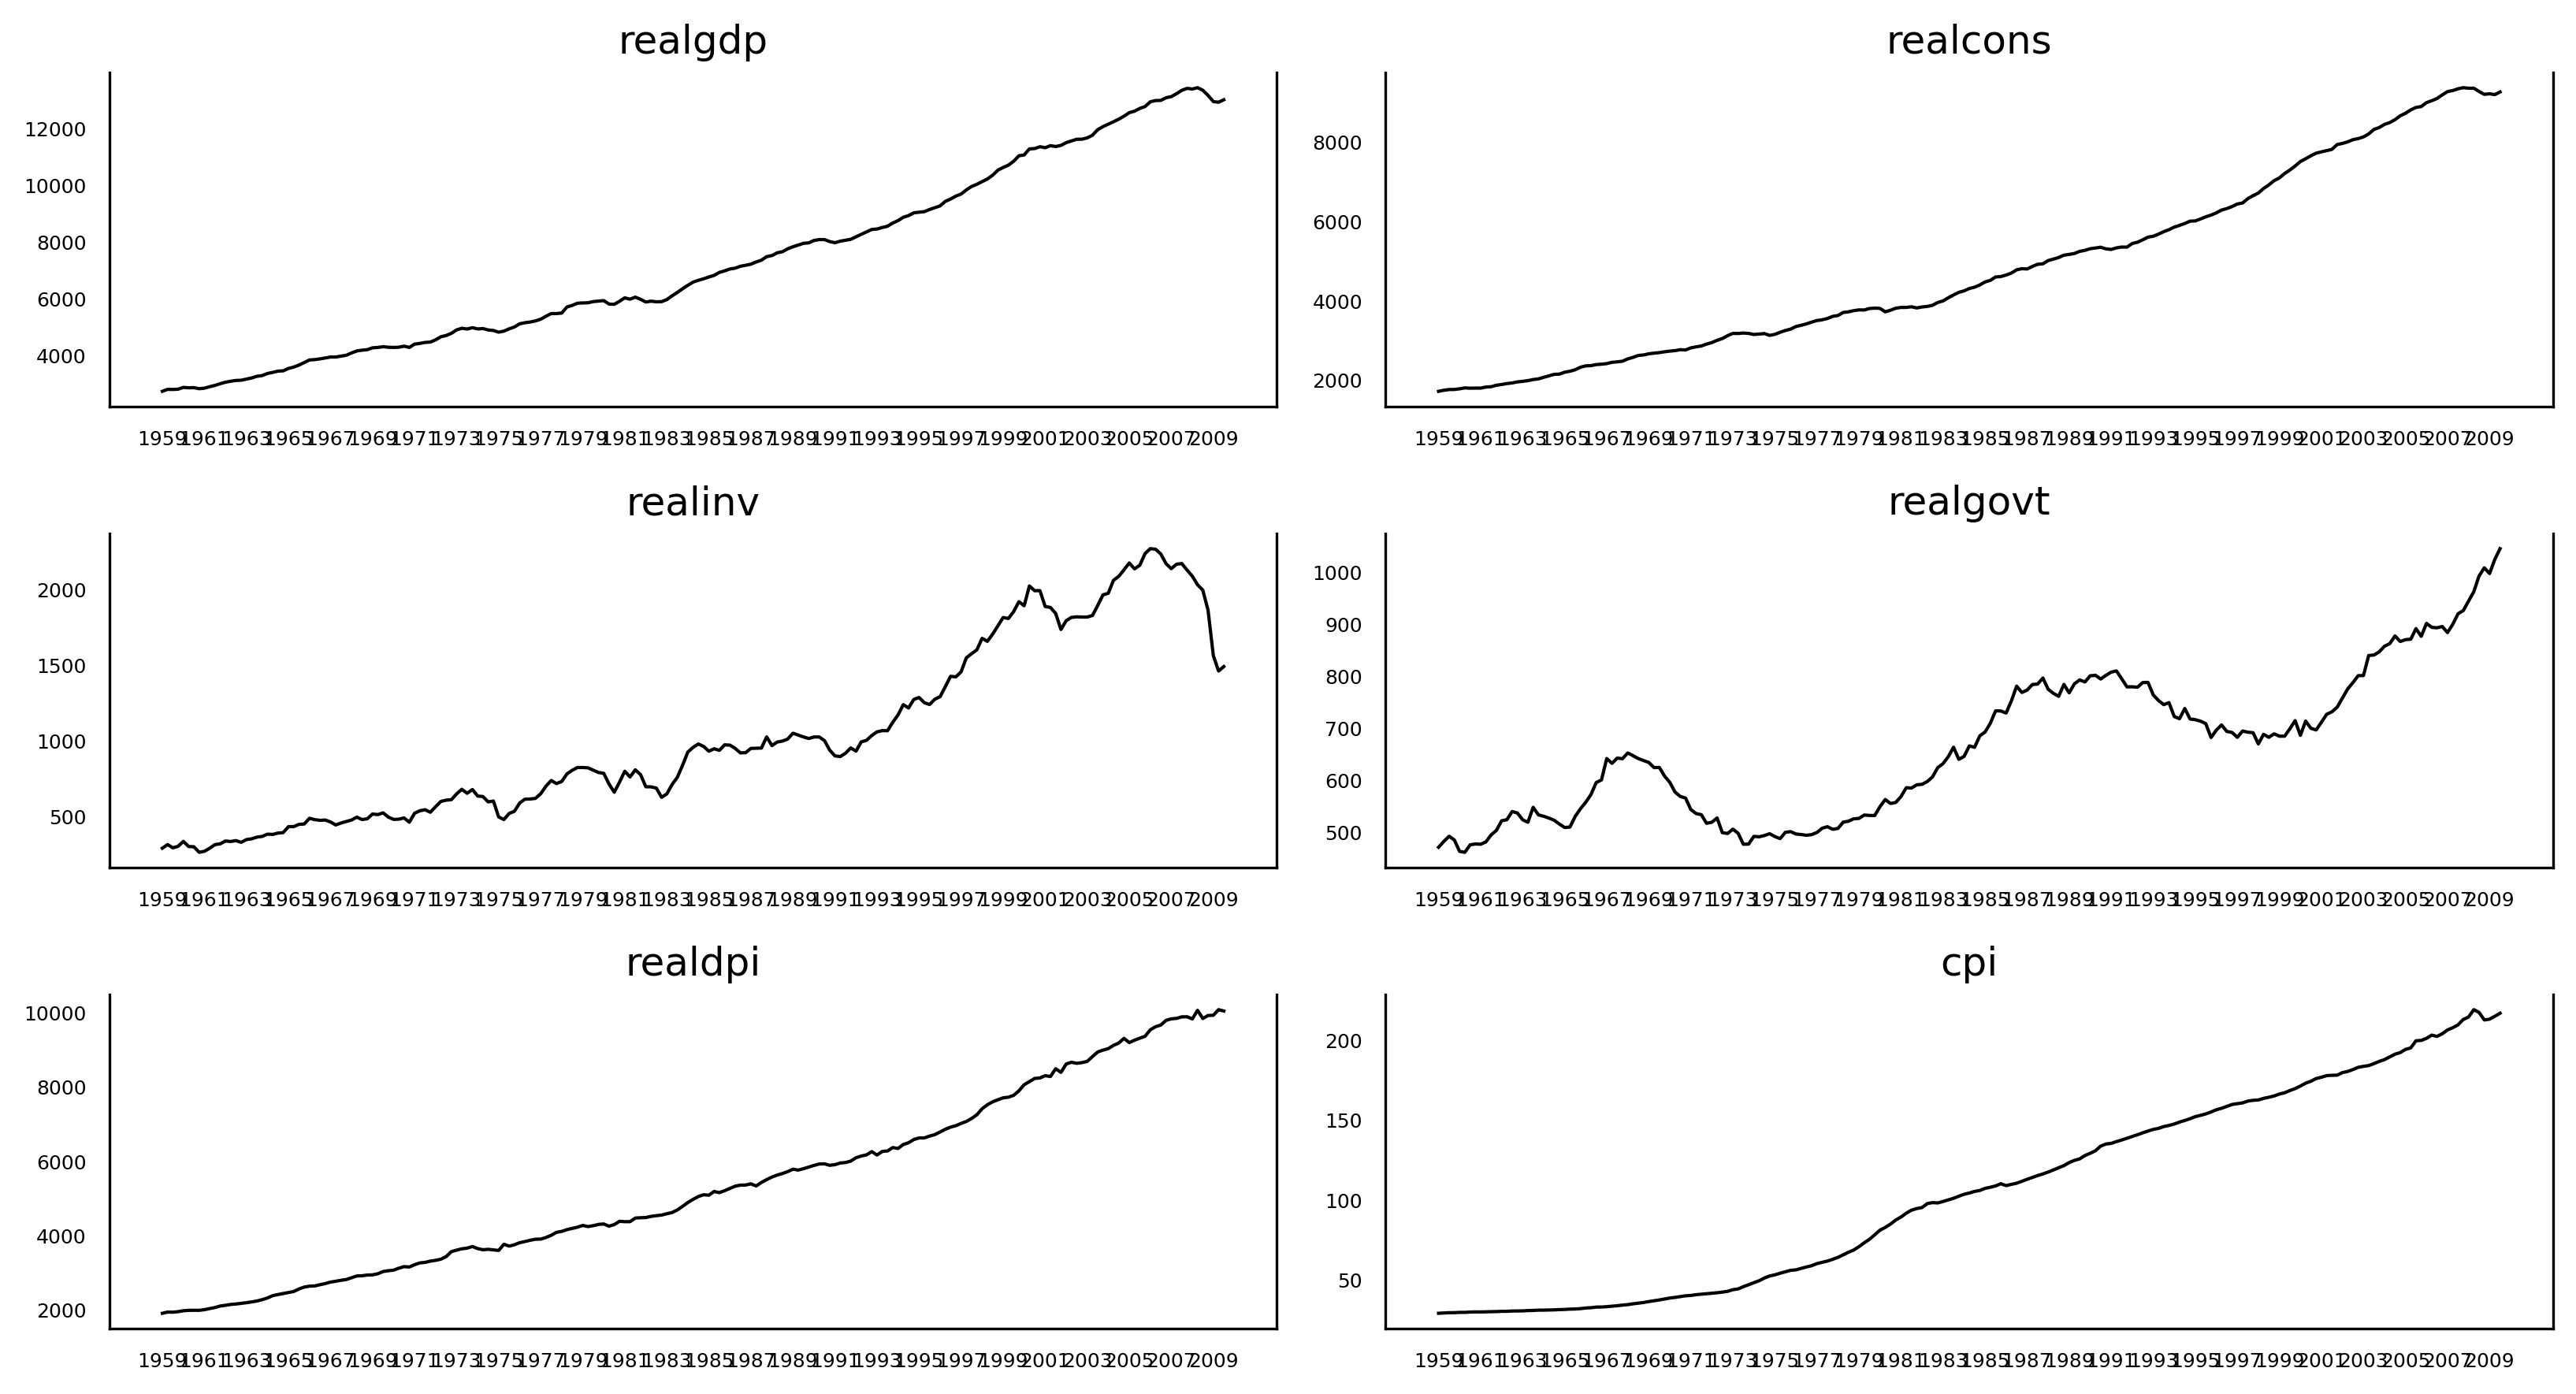

In [4]:
fix, axes = plt.subplots(nrows = 3, ncols = 2, dpi = 300, figsize = (11, 6))

for i, ax in enumerate(axes.flatten()[:6]): #6개의 변수에 대해 반복
    data = macro_econ_data[macro_econ_data.columns[i+2]] #연도 및 분기 열은 건너뜀. 그러면 realgdp 칼럼부터 시작

    ax.plot(data, color = 'black', linewidth = 1)
    ax.set_title(macro_econ_data.columns[i+2]) #도식 상단에 변수 이름 표시
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_alpha(0)
    ax.tick_params(labelsize = 6)

plt.setp(axes, xticks = np.arange(0, 208, 8), xticklabels = np.arange(1959, 2010, 2))

fig.autofmt_xdate()
plt.tight_layout()

그림 해석:
- realgdp, realcons, realdpi, cpi 모두 비슷한 모양. 시각적 분석만으로는 충분하지 않지만 realcons, realdpi, cpi가 잠재적으로 좋은 예측 변수라는 것을 알 수 있음. 반면, realgovt에서는 realgdp에는 나타나지 않는 최고점과 최저점이 있으므로 realgovt가 더 약한 예측 변수라는 가설 세울 수 있음. 

시계열 예측을 위해 외생 변수로 작업하는 방법에는 두 가지:
- <u>다양한 외생 변수의 조합</u>으로 여러 모델을 훈련하고 어떤 모델이 가장 좋은 예측을 생성하는지 확인
- 또는 모든 외생 변수를 포함한 뒤 <U>AIC를 사용</u>해 모델을 선택해도 과적합이 아닌, 잘 맞는 모델을 생성할 수 있다는 것을 알고 있으므로 단순하게 모든 외생 변수를 포함시킬수도..

---
p-값을 예측 변수와 목표 사이의 상관관계가 있는지 판단하는 방법이라고 잘못 해석.  
사실 p-값은 **계수가 0과 유의하게 다른지를 테스트**. 값이 0.05 미만이면 귀무가설을 기각하고 계수가 0과 유의하게 다르다는 결론. 이 값은 예측 변수가 예측에 유용한지 여부를 결정하지 않음.  
따라서 p-값을 기준으로 예측 변수를 제거해서는 안 됨. AIC가 가장 낮은 모델을 선택해 이 단계를 수행해야 함.  
https://robjhyndman.com/hyndsight/tests2/

## 9.1.2 SARIMAX 사용 시 주의사항

외생 변수를 포함하면 대상에 대한 강력한 예측 변수를 찾을 수도 있으므로 잠재적으로 유용. 하지만 미래의 여러 시간 단계를 예측할 때 문제.

SARIMAX는 SARIMA 모델과 외생 변수의 선형 조합을 사용해 **미래의 한 시간 단계**를 예측한다. 그러면 미래의 두 시간 단계를 예측하려면?
- SARIMA 모델을 사용하면 가능하지만, SARIMAX 모델을 사용하려면 외생 변수도 예측해야 함. 

realcons가 realgdp의 에측 변수라 가정. 또한 realgdp를 예측하기 위한 입력 특징으로 realcons를 사용하는 SARIMAX 모델이 있다고 가정.  
이제 2009년 말에 2010년과 2011년의 실질 GDP를 예측해야 한다고 가정. SARIMAX 모델을 사용하면 2009년의 realcons를 사용해 2010년의 실질 GDP를 예측할 수 있음. **그러나** 2011년의 실질 GDP를 예측하려면 2010년 말의값을 관측할 수 있을 때까지 기다리지 않는 한 2010년의 realcons를 예측해야 함.  

realcons 변수는 **그 자체가 시계열**이기 때문에 SARIMA 모델을 사용해 예측할 수 있음. 그럼에도 불구하고 예측에는 약간의 오차가 있을 수 있다는 점 유의.  
따라서 <u>목표 변수를 예측하기 위해 외생 변수를 예측해야 하는 경우에는</u> 목표 변수의 **예측 오차**가 커질 수 있으며, 이는 미래의 더 많은 시간 단계를 예측할수록 예측 정확도가 빠르게 저하될 수 있음을 뜻함.

이런 상황을 피하는 유일한 방법은 **미래의 하나의 시간 단계만 예측**하고, <u>외생 변수를 관측한 후 미래의 다른 시간 단계를 예측</u>하는 것.  

반면에 외생 변수가 예측하기 쉬운 경우, 즉 정확하게 예측할 수 있다고 알려진 예측 모델을 따른다면, 외생 변수를 예측하고 이 예측을 사용해 목표를 예측해도 아무런 문제 없음.  

결국 하나의 시간 단계만 예측하라고 정해진 권장사항은 없음. 상황과 사용 가능한 외생 변수에 따라 달라짐. 이때 데이터 사이언티스트로서 전문 지식과 엄격한 실험이 중요한 역할.  
**외생 변수를 정확하게 예측할 수 있다고 판단되면 여러 시간 단계의 미래를 예측하는 것을 추천**할 수도. 그렇지 않다면 한 번에 한 시간 단계씩 예측하고, 예측을 많이 할수록 오차가 누적되어 예측의 정확도가 떨어질 수 있음을 설명해 결정의 이유를 명확히 해야. 

# 9.2 SARIMAX 모델을 사용해 실질 GDP 예측

데이터 집합의 외생 변수를 살펴본 후 이를 에측 모델에 통합.  

일반적인 모델링 절차에 큰 변화는 없으나, SARIMAX 모델을 이제 적용한다는 점. 

In [5]:
from statsmodels.tsa.stattools import adfuller

target = macro_econ_data['realgdp'] #dep var 설정
exog = macro_econ_data[['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi']]

ad_fuller_result = adfuller(target)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'p-val: {ad_fuller_result[1]}')

ADF Stats: 1.7504627967647095
p-val: 0.9982455372335032


In [6]:
# 수열 비정상적이니 변환(차분)
target_diff = target.diff()

ad_fuller_result = adfuller(target_diff[1:])

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'p-val: {ad_fuller_result[1]}')

ADF Stats: -6.305695561658102
p-val: 3.327882187668259e-08


이제 수열이 정상적 상태라 결론. d = 1.  
시계열을 정상적 상태로 만들기 위해 계절적 차분을 할 필요는 없으니 D = 0.

In [9]:
# 모든 고유한 조합을 피팅하고 AIC 기준 오름차순으로 df 반환하는 optimize_SARIMAX 함수 정의.

from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], 
                     order_list: list, d: int, D: int, s: int) -> pd.DataFrame: #endog: 관측된 시계열 데이터
    # 여기서 s은 SARIMA의 m
    # 고유 (p,q) 조합들의 목록, 적분 차수 d를 입력받는다. 
    results = [] 

    for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.
        try:
            model = SARIMAX(endog, 
                            exog, 
                            order = (order[0], d, order[1]),
                            seasonal_order=(order[2], D, order[3], s), 
                            simple_differencing=False).fit(disp = False) #SARIMAX 함수를 사용해 ARMA(p,d,q) 모델 피팅. 
                            #차분이 되지 않도록 simple_differencing을 False.
                            # 콘솔에 상태 메시지 안 나오도록 disp = False.
                            # order = (p,d,P,D)
        except:
            continue

        aic = model.aic #모델의 aic 계산.
        results.append([order,aic]) #결과 목록에 (p,q) 조합과 AIC를 튜플로 추가.

    result_df = pd.DataFrame(results) #(p,q) 조합과 AIC를 DataFrame에 저장
    result_df.columns = ['(p,q,P,Q)', 'AIC'] #DataFrame의 열에 레이블 지정

    # ascending order as lower AIC is better
    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True) #AIC값을 기준으로 오름차순 정렬.

    return result_df

In [11]:
# 이제 차수 p,q,P,Q에 대해 가능한 값의 범위 지정. 0에서 3까지 값 사용하겠지만 다른 범위의 값도 사용 가능.  
# 분기별 데이터이므로 m = 4
from itertools import product

p = range(0,4,1)
d = 1
q = range(0,4,1)
P = range(0,4,1)
D = 0
Q = range(0,4,1)
s = 4 # m과 동일

parameters = product(p,q,P,Q)
parameters_list = list(parameters)

In [12]:
# 모델 training 위해 목표 변수와 외생 변수의 처음 200개 사용. 그 다음 optimize_SARIMAX 함수를 통해 AIC가 가장 낮은 모델 선택.

target_train = target[:200]
exog_train = exog[:200]

result_df = optimize_SARIMAX(target_train, exog_train, parameters_list, d, D, s)
result_df

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_87558/3274746664.py:13: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.


  0%|          | 0/256 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

,"(p,q,P,Q)",AIC
0,"(3, 3, 0, 0)",1742.832816
1,"(3, 3, 1, 0)",1744.967536
2,"(3, 3, 0, 1)",1744.997182
3,"(2, 2, 0, 0)",1745.498066
4,"(3, 3, 2, 2)",1746.281163
...,...,...
251,"(0, 2, 0, 0)",1761.579044
252,"(0, 3, 0, 0)",1762.317095
253,"(0, 0, 0, 0)",1764.754980
254,"(1, 0, 0, 0)",1765.379412


SARIMAX(3,1,3)(0,0,0)_4 모델이 가장 낮은 AIC.  
Seasonal은 차수가 0이므로, 윗 공식은 결국 ARIMAX(3,1,3)과 같음.  
맨 윗 도식에서 real gdp는 계절적 패턴이 없기에 이는 당연한 결과. 

In [13]:
# model fitting

best_model = SARIMAX(target_train, exog_train, order = (3,1,3), seasonal_order=(0,0,0,4), simple_differencing = False)
best_model_fit = best_model.fit(disp = False)

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  200
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -859.416
Date:                Wed, 09 Sep 2026   AIC                           1742.833
Time:                        22:09:23   BIC                           1782.352
Sample:                             0   HQIC                          1758.827
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9670      0.045     21.618      0.000       0.879       1.055
realinv        1.0136      0.033     30.850      0.000       0.949       1.078
realgovt       0.7283      0.127      5.740      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


realdpi를 제외한 모든 외생 변수의 p-값이 0.05보다 작다.
- realdpi의 계수가 0에 가깝다는 뜻.
- 하지만 p-값이 대상과 예측 변수의 연관성을 결정짓지는 않으니 계수는 모델에 유지.

다음으로 모델의 잔차 분석

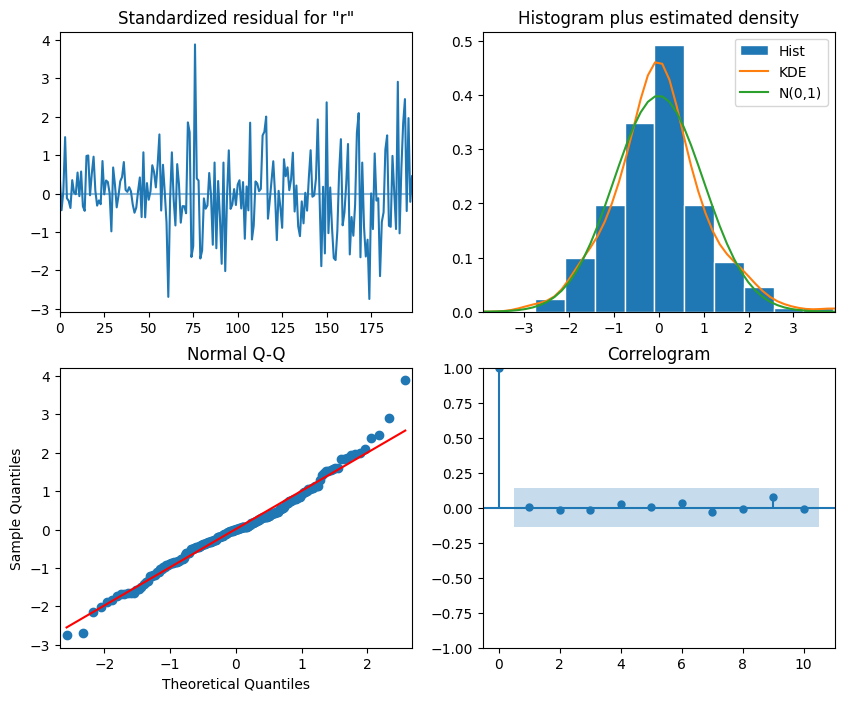

In [16]:
best_model_fit.plot_diagnostics(figsize = (10,8));

잔차: 백색소음처럼 시간이 지남에 따라 추세가 없고 상당히 일정한 분산을 보임. 
- 우측 상단: 잔차의 분포 매우 정규분포
- 좌측 하단: y=x 직선에 상당히 겹쳐진 직선
- 우측 하단: 지연 0 이후에는 유의한 계수가 없음.

이제 잔차가 상관관계가 없는지 확인하기 위해 Ljung Box Test

In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = best_model_fit.resid

result = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(result)

     lb_stat  lb_pvalue
1   0.081995   0.774612
2   0.210074   0.900291
3   0.214857   0.975156
4   1.189010   0.879905
5   1.190985   0.945739
6   1.210866   0.976345
7   1.410619   0.985244
8   1.421577   0.993935
9   1.793346   0.994330
10  1.798225   0.997666


모두 p-val이 0.05보다 크므로 귀무가설을 기각되지 않음. 잔차가 독립적이고 상관관계가 없다고 내릴 수 있다.  
SARIMAX 모델 사용시 주의점:
- 외생 변수를 예측하면 최종 예측에 예측 오차가 누적될 수 있으니 바로 다음 시간 단계만 예측하는 것이 적절.

대신, 모델을 테스트하기 위해 다음 시간 단계를 여러 번 예측하고 각 예측의 오차를 평균. `rolling_forecast` 함수를 사용하여 수행.

In [18]:
def rolling_forecast(endog: Union[pd.Series, list], exog: Union[pd.Series, list],
                     train_len: int, horizon: int, window: int, method: str) -> list:
    #window: 한 번에 예측할 시간 단계 횟수 지정 (MA(2)일 경우 window = 2)
    
    total_len = train_len + horizon

    if method == 'last': # 최근값 기반
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = endog[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
        
        return pred_last_value
    
    elif method == 'SARIMAX':
        pred_SARIMAX = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog[:i], order = (3,1,3), seasonal_order=(0,0,0,4),
                            simple_differencing= False)  #order = (p,d,q) 순서;
            res = model.fit(disp = False)
            predictions = res.get_prediction(exog = exog)
            oos_pred = predictions.predicted_mean.iloc[-window:] # predicted_mean을 토해 예측한 실젯값을 추출
            pred_SARIMAX.extend(oos_pred)

        return pred_SARIMAX

In [19]:
# 특정 기간 동안의 다음 시간 단계를 예측.
# 이 함수를 활용해 2008년부터 2009년 3분기까지의 다음 시간 단계를 구체적으로 예측.

target_train = target[:196] # 1959년 - 2007년 말까지의 데이터에 모델 피팅
target_test = target[196:] # 테스트 집합에는 2008년부터 2009년 3분기까지의 값이 포함. 예측할 값은 총 7개

pred_df = pd.DataFrame({'actual': target_test})

TRAIN_LEN = len(target_train)
HORIZON = len(target_test)
WINDOW = 1

pred_last_value = rolling_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_SARIMAX = rolling_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX')

pred_df['pred_last_value'] = pred_last_value
pred_df['pred_SARIMAX'] = pred_SARIMAX

pred_df

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

,actual,pred_last_value,pred_SARIMAX
196,13366.865,13391.249,13344.062928
197,13415.266,13366.865,13373.512189
198,13324.600,13415.266,13378.816575
199,13141.920,13324.600,13327.758355
200,12925.410,13141.920,13133.746954
201,12901.504,12925.410,12887.097037
202,12990.341,12901.504,12873.797125


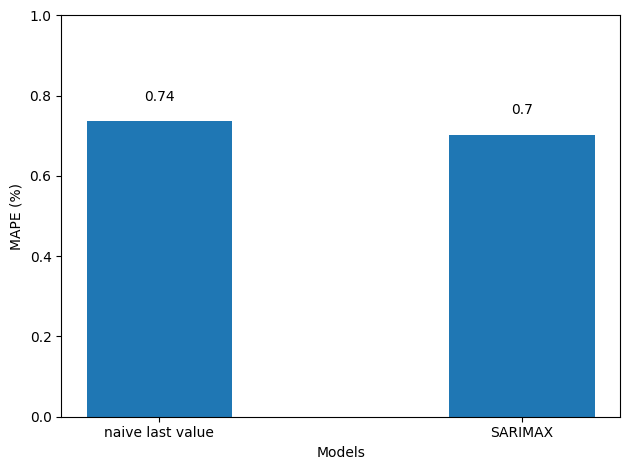

In [20]:
# 이제 MAPE가 가장 낮은지 시각화

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_last = mape(pred_df.actual, pred_df.pred_last_value)
mape_SARIMAX = mape(pred_df.actual, pred_df.pred_SARIMAX)

fig, ax = plt.subplots()

x = ['naive last value', 'SARIMAX']
y = [mape_last, mape_SARIMAX]

ax.bar(x, y, width = 0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0,1)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.05, s = str(round(value, 2)), ha = 'center')

plt.tight_layout()

윗 그림에서 SARIMAX 모델이 0.04% 차이로 승리한 모델.  
베이스라인의 중요성:
- 비즈니스적 맥락이 중요한 역할. 
    - 여기서는 미국의 실질 GDP를 예측하는 것이므로, 0.04%의 차이는 수천 달러에 해당. 
    - 이 수치 차이는 베이스라인 모델보다 약간 더 좋은 성능으로 보인다 해도 맥락 상에서는 중요할 수도 있음.



# 9.3 다음

시간에 따라 달라지는 두 변수가 서로 영향을 미칠 수 있음을 입증하고자 할 때는 벡터자기회귀$_{\text{VAR}}$ 모델 사용. 
- 단변량 시계열 예측이 가능한 SARIMAX 모델과 달리 다변량$_{\text{multivariate}}$ 시계열 예측이 가능. 
- 확장하여 VARMA와 VARMAX 모델로도 가능.